## 1) Imports

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

## 2) Config

In [2]:
TARGET = "hpi"  # "HPI_YoY"

EXOG_VARS = [
    "FLOOD_FREQUENCY",
    "FLOOD_PROPERTY_DAMAGE",
    "FLOOD_DURATION_HOURS",
    "HEAT_VALUE",
    "HEAT_INDEX",
    "HSI",
    "DROUGHT_ANNUAL_MEAN_INDEX",
    "FIRE_FREQUENCY",
    "FIRE_SIZE",
    "deaths_hurricane",
    "injuries_hurricane",
    "damage_hurricane",
]

STATIC_VARS = ["county_fips"]  # e.g. "population", "elevation", "urban_rural_code"

FORECAST_YEARS = 10
SEQ_LEN = 10  # 10 YEAR WINDOW FOR LSTM

## 3. Exogenous forecasting function

In [3]:
def try_arima_or_hw(series, steps):
    """Try ARIMA; fallback to Holt-Winters if ARIMA fails."""
    series = pd.Series(series).astype(float)

    try:
        model = ARIMA(series, order=(1, 1, 1)).fit()
        fc = model.forecast(steps)
        return np.array(fc)
    except:
        model = ExponentialSmoothing(series, trend="add").fit()
        fc = model.forecast(steps)
        return np.array(fc)

## 4) Forecast all exogenous variables

In [4]:
def forecast_all_exogs(df, steps, static_variables_dict=None):
    future = {}

    for var in EXOG_VARS:
        # print(f"Forecasting exogenous variable: {var}")
        series = df[var].values
        future[var] = try_arima_or_hw(series, steps)

    if static_variables_dict:
        for var in STATIC_VARS:
            static_value = static_variables_dict[var]
            # future[var] = np.repeat(static_value, steps)
            # future = np.column_stack([future[var] for var in EXOG_VARS + (STATIC_VARS if static_variables_dict else [])])

            future_with_static = np.concatenate(
                future, np.repeat([static_value], steps, axis=0), axis=1
            )

    return pd.DataFrame(future_with_static if static_variables_dict else future)

## 5) Prepare multivariate LSTM dataset

In [5]:
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])  # (seq_len, num_features)
        y.append(data[i + seq_len][0])  # next-step HPI_YoY
    return torch.tensor(X).float(), torch.tensor(y).float().unsqueeze(-1)

## 6) LSTM Model

In [6]:
class LSTMModel(nn.Module):
    def __init__(self, num_features, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(num_features, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # last timestep output
        return self.fc(out)

## 7) Train LSTM

In [7]:
def train_with_validation(
    df, epochs, add_county_fips=False, patience=20, checkpoint_path="best_lstm.pt"
):

    # ---------------------
    # STEP 1: Build dataset with HPI + exogs
    # ---------------------
    cols = EXOG_VARS + STATIC_VARS if add_county_fips else EXOG_VARS
    full_df = pd.concat([df[[TARGET] + cols]], ignore_index=True, axis=0)

    data = full_df.values

    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    # ---------------------
    # STEP 2: Create sequences
    # ---------------------
    X, y = create_sequences(data_scaled[: len(df)], SEQ_LEN)

    # ---------------------
    # STEP 3: Train/Val Split (80/20)
    # ---------------------
    train_size = int(0.8 * len(X))
    X_train, X_val = X[:train_size], X[train_size:]
    y_train, y_val = y[:train_size], y[train_size:]

    # Convert to torch
    X_train = torch.tensor(X_train).float()
    y_train = torch.tensor(y_train).float()
    X_val = torch.tensor(X_val).float()
    y_val = torch.tensor(y_val).float()

    # ---------------------
    # STEP 4: Model + Loss + Optimizer
    # ---------------------
    model = LSTMModel(num_features=data.shape[1])
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.003)

    # For tracking
    train_losses = []
    val_losses = []

    # Early stopping
    best_val_loss = float("inf")
    patience_counter = 0

    # ---------------------
    # STEP 5: Training Loop
    # ---------------------
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        pred = model(X_train)
        loss = criterion(pred, y_train)
        loss.backward()
        optimizer.step()

        # ---- Validation ----
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, y_val)

        # Track losses
        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        # Print occasionally
        if (epoch + 1) % 100 == 0:
            print(
                f"Epoch {epoch+1}/{epochs} | Train Loss: {loss.item():.6f} | Val Loss: {val_loss.item():.6f}"
            )

        # ---- Early Stopping Check ----
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0

            # Save best checkpoint
            torch.save(model.state_dict(), checkpoint_path)
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    print(f"Best validation loss: {best_val_loss:.6f}")

    # Load best weights
    model.load_state_dict(torch.load(checkpoint_path))

    # ---------------------
    # STEP 6: Test Set Evaluation (last 20% of df)
    # ---------------------
    y_val_pred = model(X_val).detach().numpy()

    # Inverse scaling
    def invert(values):
        pad = np.zeros(
            (len(values), len(EXOG_VARS) + (len(STATIC_VARS) if add_county_fips else 0))
        )
        return scaler.inverse_transform(np.concatenate([values, pad], axis=1))[:, 0]

    y_val_inv = invert(y_val.numpy())
    y_val_pred_inv = invert(y_val_pred)

    # ---------------------
    # STEP 7: Plot predictions
    # ---------------------
    plt.figure(figsize=(10, 5))
    plt.plot(y_val_inv, label="Actual")
    plt.plot(y_val_pred_inv, label="Predicted", linestyle="--")
    plt.title("LSTM Validation Prediction")
    plt.xlabel("Test Data Point Index")
    plt.ylabel("HPI_YoY")
    plt.grid(True)
    plt.legend()
    plt.show()

    # ---------------------
    # STEP 8: Loss curves
    # ---------------------
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.title("Loss Curves")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ------------------------
    # STEP 9: Accuracy metrics
    # ------------------------
    mae = mean_absolute_error(y_val_inv, y_val_pred_inv)
    rmse = np.sqrt(mean_squared_error(y_val_inv, y_val_pred_inv))
    r2 = r2_score(y_val_inv, y_val_pred_inv)

    mape = np.mean(np.abs((y_val_inv - y_val_pred_inv) / (y_val_inv + 1e-9))) * 100
    smape = 100 * np.mean(
        2
        * np.abs(y_val_inv - y_val_pred_inv)
        / (np.abs(y_val_inv) + np.abs(y_val_pred_inv) + 1e-9)
    )

    print("\nVALIDATION FORECAST ACCURACY")
    print("----------------------------")
    print(f"MAE:   {mae:.4f}")
    print(f"RMSE:  {rmse:.4f}")
    print(f"R²:    {r2:.4f}")
    print(f"MAPE:  {mape:.2f}%")
    print(f"SMAPE: {smape:.2f}%")

    return model, (train_losses, val_losses)

## 8) Forecast Future HPI

In [8]:
def forecast(model, base_exog_df, no_of_years, static_variables_dict=None):

    # -------------------------------------------
    # STEP 1: Forecast exogenous variables
    # -------------------------------------------
    future_exog_df = forecast_all_exogs(
        base_exog_df, no_of_years, static_variables_dict
    )

    exog_cols = list(future_exog_df.columns)

    # -------------------------------------------
    # STEP 2: Scale exogenous variables
    # -------------------------------------------
    exog_scaler = MinMaxScaler()
    base_exogs_scaled = exog_scaler.fit_transform(base_exog_df[exog_cols])
    future_exogs_scaled = exog_scaler.transform(future_exog_df[exog_cols])

    # -------------------------------------------
    # STEP 3: Scale target separately (fit on actual HPI history)
    # -------------------------------------------
    target_scaler = MinMaxScaler()
    target_series = base_exog_df["HPI_YoY"].values.reshape(-1, 1)
    target_scaler.fit(target_series)

    # Initialize the window from the end of training
    history = np.concatenate(
        [target_scaler.transform(target_series), base_exogs_scaled], axis=1
    )

    window = torch.tensor(history[-SEQ_LEN:], dtype=torch.float32).unsqueeze(0)

    future_preds_scaled = []

    # -------------------------------------------
    # STEP 4: Autoregressive Forecast Loop
    # -------------------------------------------
    for i in range(no_of_years):

        # model outputs scaled prediction
        output = model(window)
        pred_scaled = output.detach().numpy()[0, 0]
        future_preds_scaled.append(pred_scaled)

        # get scaled exogs for current step
        next_exogs_scaled = future_exogs_scaled[i]

        # build next row (scaled target + scaled exogs)
        next_row = np.concatenate([[pred_scaled], next_exogs_scaled])
        next_row = torch.tensor(next_row, dtype=torch.float32).reshape(1, 1, -1)

        # slide window
        window = torch.cat((window[:, 1:, :], next_row), dim=1)

    # -------------------------------------------
    # STEP 5: Invert scaling on predictions
    # -------------------------------------------
    future_preds = target_scaler.inverse_transform(
        np.array(future_preds_scaled).reshape(-1, 1)
    ).flatten()

    return future_preds, future_exog_df

## 9) Run Pipeline

In [9]:
climate_hpi = pd.read_csv(
    "../../02_processed_data/wildfire_drought_hpi_flood_heat_huricane.csv"
)
climate_hpi = climate_hpi.rename(
    columns={"hpi_yoy": "HPI_YoY", "county_fips5": "county_fips"}
)
climate_hpi

,yr,HPI_YoY,hpi,STATE,CZ_NAME,FLOOD_FREQUENCY,FLOOD_PROPERTY_DAMAGE,FLOOD_DURATION_HOURS,HEAT_VALUE,HEAT_INDEX,HSI,DROUGHT_ANNUAL_MEAN_INDEX,FIRE_FREQUENCY,FIRE_SIZE,deaths_hurricane,injuries_hurricane,damage_hurricane
0,2000,1.226954,115.7100,0,0,0.0,0.0,0.00,94.4,0.289948,0.509057,-3.36,0.0,0.00,0.0,0.0,0.0
1,2001,4.070521,120.4200,0,0,0.0,0.0,0.00,95.7,0.353297,0.587194,0.39,0.0,0.00,0.0,0.0,0.0
2,2002,2.850440,123.8525,TEXAS,CALLAHAN,2.0,807000.0,14.08,90.8,0.059089,0.323792,1.54,0.0,0.00,0.0,0.0,0.0
3,2003,2.620052,127.0975,TEXAS,CALLAHAN,2.0,0.0,2.00,92.8,0.178862,0.442478,0.96,1.0,100.00,0.0,0.0,0.0
4,2004,4.455241,132.7600,TEXAS,CALLAHAN,4.0,100000.0,4.18,89.6,-0.000561,0.413233,2.28,19.0,61.00,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21960,2016,3.794342,171.2425,ARIZONA,YUMA,3.0,0.0,3.00,106.9,0.414770,0.872492,-2.68,11.0,1326.60,0.0,0.0,0.0
21961,2017,3.854183,177.8425,0,0,0.0,0.0,0.00,107.2,0.419574,0.878639,-2.05,17.0,103.00,0.0,0.0,0.0
21962,2018,3.642268,184.3200,ARIZONA,YUMA,7.0,65000.0,17.83,106.4,0.402691,0.818690,-2.95,191.0,594.87,0.0,0.0,0.0
21963,2019,5.189345,193.8850,ARIZONA,YUMA,2.0,2000.0,7.87,106.7,0.410549,0.944888,-0.23,64.0,1265.91,0.0,0.0,0.0


### Train

Epoch 100/4000 | Train Loss: 0.009865 | Val Loss: 0.008827
Epoch 200/4000 | Train Loss: 0.004606 | Val Loss: 0.003999
Epoch 300/4000 | Train Loss: 0.004060 | Val Loss: 0.003480
Epoch 400/4000 | Train Loss: 0.001991 | Val Loss: 0.002168
Epoch 500/4000 | Train Loss: 0.001158 | Val Loss: 0.001423
Epoch 600/4000 | Train Loss: 0.000886 | Val Loss: 0.001109
Epoch 700/4000 | Train Loss: 0.000730 | Val Loss: 0.000938
Epoch 800/4000 | Train Loss: 0.000718 | Val Loss: 0.000869
Epoch 900/4000 | Train Loss: 0.000529 | Val Loss: 0.000727
Epoch 1000/4000 | Train Loss: 0.000528 | Val Loss: 0.000716
Epoch 1100/4000 | Train Loss: 0.000402 | Val Loss: 0.000570
Epoch 1200/4000 | Train Loss: 0.000384 | Val Loss: 0.000576
Epoch 1300/4000 | Train Loss: 0.000317 | Val Loss: 0.000454
Epoch 1400/4000 | Train Loss: 0.000716 | Val Loss: 0.000966
Epoch 1500/4000 | Train Loss: 0.000302 | Val Loss: 0.000435
Early stopping triggered at epoch 1503
Best validation loss: 0.000430


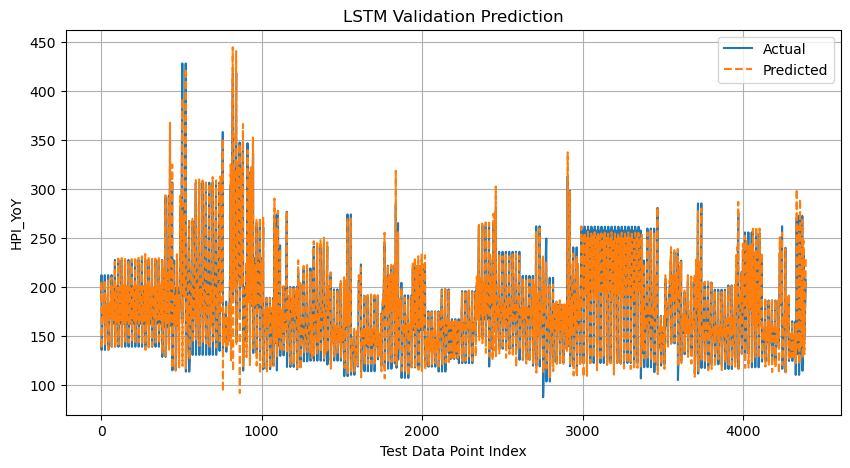

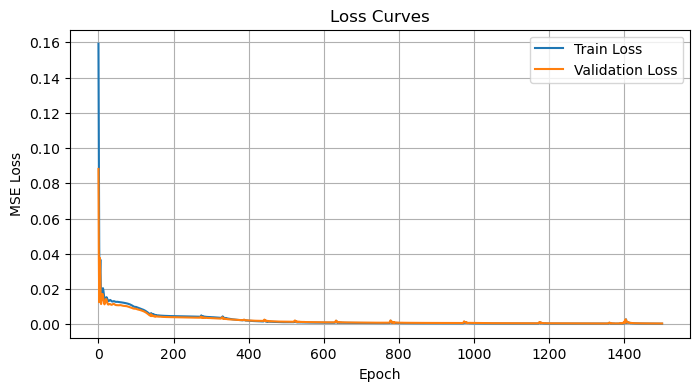


VALIDATION FORECAST ACCURACY
----------------------------
MAE:   4.7603
RMSE:  8.0321
R²:    0.9626
MAPE:  2.79%
SMAPE: 2.75%


In [10]:
model, train_val_loss = train_with_validation(climate_hpi, 4000, False, 150)

### Forecast

In [11]:
NO_OF_YEARS = 4


def forecast_county(df_county):
    future_hpi, future_exogs = forecast(model, df_county, NO_OF_YEARS, None)
    # future_hpi, future_exogs = forecast_new(model, scalar, df_county, NO_OF_YEARS)

    years = list(
        range(df_county["yr"].max() + 1, df_county["yr"].max() + 1 + NO_OF_YEARS)
    )

    result = pd.DataFrame(
        {
            "yr": years,
            "county_fips": df_county["county_fips"].iloc[0],
            "HPI_YoY": future_hpi.flatten(),
        }
    )

    result = pd.concat([result, future_exogs], axis=1)
    return result

In [12]:
all_results = []

for fips in climate_hpi["county_fips"].unique():  # [0:10]:
    df_county = climate_hpi[climate_hpi["county_fips"] == fips].sort_values("yr")
    res = forecast_county(df_county)
    all_results.append(res)

all_results = pd.concat(all_results, ignore_index=True)
print("\nForecast Results for Multiple Counties:\n")
all_results

KeyError: 'county_fips'